In [1]:
import numpy as np
import matplotlib.pyplot as plt

hbar = 1.054571817e-34
m_e = 9.1093837e-31
eV = 1.602176634e-19

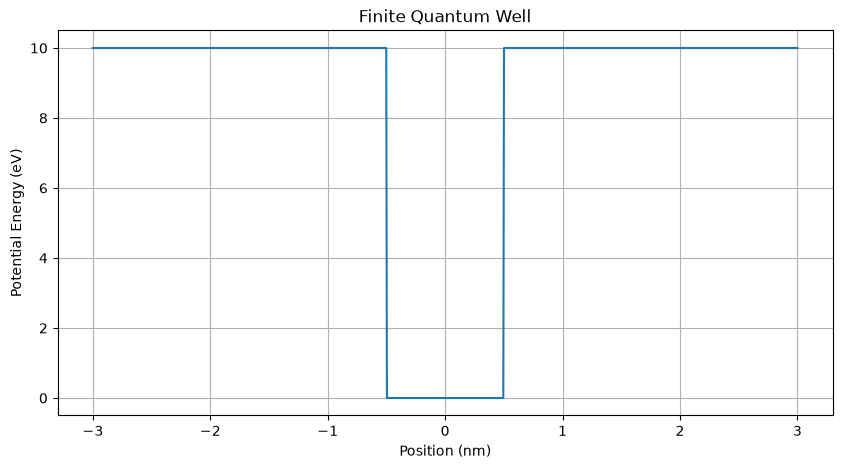

In [2]:
# Spatial grid
L = 6e-9
N = 1000

x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Finite well parameters
well_width = 1e-9
V0 = 10 * eV

# Outside = 10 eV, inside well = 0 eV
V = np.full(N, V0)
V[np.abs(x) <= well_width/2] = 0

plt.figure(figsize=(10, 5))
plt.plot(x * 1e9, V / eV)

plt.xlabel("Position (nm)")
plt.ylabel("Potential Energy (eV)")
plt.title("Finite Quantum Well")
plt.grid(True)
plt.show()

In [3]:
# Use interior points
x_int = x[1:-1]
V_int = V[1:-1]

M = len(x_int)

# Finite-difference second derivative
main_diag = -2.0 * np.ones(M)
off_diag = np.ones(M - 1)

D2 = (
    np.diag(main_diag)
    + np.diag(off_diag, 1)
    + np.diag(off_diag, -1)
) / dx**2

# Kinetic-energy operator
T_operator = -(hbar**2 / (2 * m_e)) * D2

# Potential-energy operator
V_operator = np.diag(V_int)

# Full Hamiltonian
H = T_operator + V_operator

print("Hamiltonian size:", H.shape)

Hamiltonian size: (998, 998)


In [4]:
energies, wavefunctions = np.linalg.eigh(H)

energies_eV = energies / eV

print("Lowest energy levels:")

for n in range(8):
    print(f"n = {n+1}: E = {energies_eV[n]:.4f} eV")

Lowest energy levels:
n = 1: E = 0.2991 eV
n = 2: E = 1.1922 eV
n = 3: E = 2.6648 eV
n = 4: E = 4.6848 eV
n = 5: E = 7.1753 eV
n = 6: E = 9.7970 eV
n = 7: E = 10.0593 eV
n = 8: E = 10.0728 eV


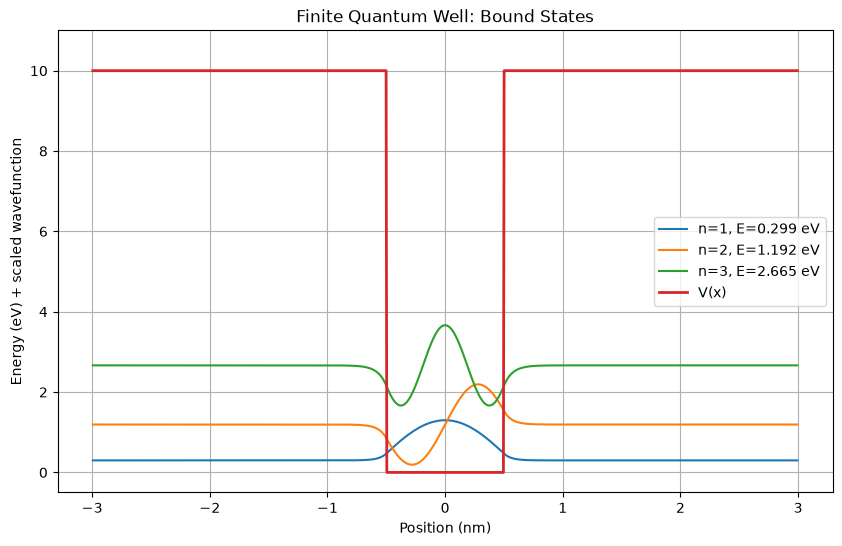

In [5]:
# Plot the first three bound-state wavefunctions
plt.figure(figsize=(10, 6))

for n in range(3):
    psi = wavefunctions[:, n]

    norm = np.sqrt(
        np.trapezoid(np.abs(psi)**2, x_int)
    )
    psi = psi / norm

    # Scale wavefunction for visualization
    psi_scaled = psi / np.max(np.abs(psi))

    plt.plot(
        x_int * 1e9,
        psi_scaled + energies_eV[n],
        label=f"n={n+1}, E={energies_eV[n]:.3f} eV"
    )

# Plot potential
plt.plot(
    x_int * 1e9,
    V_int / eV,
    linewidth=2,
    label="V(x)"
)

plt.xlabel("Position (nm)")
plt.ylabel("Energy (eV) + scaled wavefunction")
plt.title("Finite Quantum Well: Bound States")
plt.ylim(-0.5, 11)
plt.legend()
plt.grid(True)
plt.show()

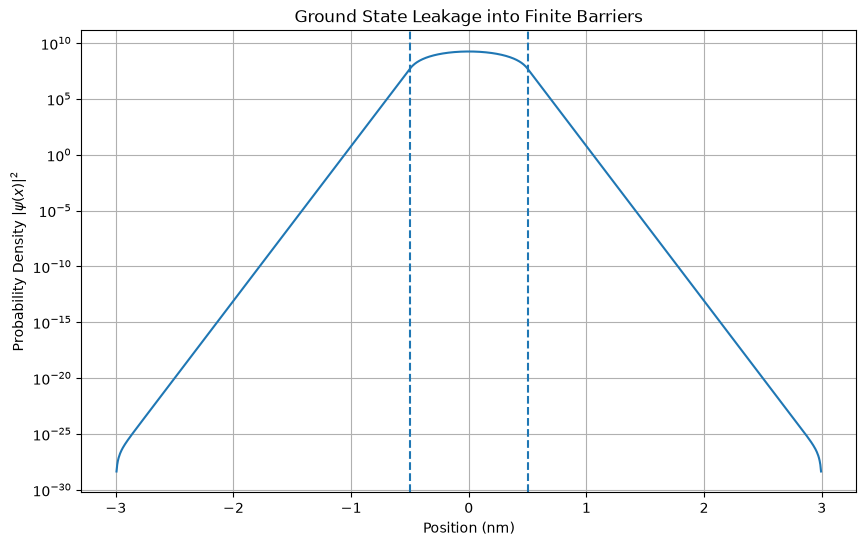

In [6]:
# Ground-state wavefunction
psi = wavefunctions[:, 0]

# Normalize
norm = np.sqrt(
    np.trapezoid(np.abs(psi)**2, x_int)
)
psi = psi / norm

# Probability density
probability = np.abs(psi)**2

plt.figure(figsize=(10, 6))

plt.semilogy(
    x_int * 1e9,
    probability
)

# Mark well boundaries
plt.axvline(-well_width/2 * 1e9, linestyle="--")
plt.axvline(well_width/2 * 1e9, linestyle="--")

plt.xlabel("Position (nm)")
plt.ylabel(r"Probability Density $|\psi(x)|^2$")
plt.title("Ground State Leakage into Finite Barriers")
plt.grid(True)

plt.show()